[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aims-foundations/torch_measure/blob/main/tutorials/araf.ipynb)

# ARAF: Amortized Multidimensional Factor Model for Agent Evaluation

This tutorial demonstrates how to train an **ARAF** (Automatic Relevance Amortized Factors) model that predicts agent performance on benchmark items from a partially observed (agents × items) score matrix and pre-computed item embeddings.

Following [agent-eval (2026)](https://github.com/aims-foundations/agent-eval), ARAF combines (i) a multidimensional latent ability $\theta_i \in \mathbb{R}^K$ per agent, (ii) item loadings amortized from item embeddings $x_j$ via a shared projection $W$, and (iii) an Automatic Relevance Determination (ARD) gate $\tau \in \mathbb{R}_{\ge 0}^K$ that prunes irrelevant latent dimensions. The key insight: in the small-$N$, large-$J$ regime of agent evaluation, fitting free per-item parameters is unstable. Amortizing them through a shared map $W$ trades $JK$ free parameters for $Kd$ shared ones.

**What you'll learn:**
1. Loading AfriMedQA benchmark data using `torch_measure.datasets`
2. Generating item embeddings from question text using a sentence encoder
3. Training an `ARAF` model that maps embeddings to multidimensional item loadings
4. Evaluating in-sample fit and zero-shot generalization to held-out items
5. Inspecting the recovered effective rank and learned per-agent abilities

## 1. Setup

In [1]:
try:
    import google.colab
    !git clone https://github.com/aims-foundations/torch_measure.git
    !pip install -e "torch_measure[data]" sentence-transformers
except ImportError:
    pass  # Already installed locally

import torch
import matplotlib.pyplot as plt
import numpy as np

from torch_measure.datasets import load, list_datasets, info
from torch_measure.data import ResponseMatrix
from torch_measure.models import ARAF, TwoPL, predict_dense
from torch_measure.metrics import expected_calibration_error, brier_score

plt.rcParams["figure.dpi"] = 120
torch.manual_seed(42)
print("Setup complete.")

Setup complete.


---
## Part 1: Ground-Truth Recovery on Synthetic Data

Before applying ARAF to a real benchmark we check the basic mechanic: given item embeddings whose only signal directions are a known low-rank subspace, and Bernoulli responses generated from a $K^\star$-factor model, can ARAF (i) recover the rank $K^\star$ via ARD and (ii) recover the loading subspace? If yes, then any signal we see on real data is coming from the model, not from the infrastructure.

The probabilistic model (Eqs. 3–5 in agent-eval, 2026) is

$$a_j = \tau \odot (\bar{W} x_j), \quad \delta_j = b^\top x_j, \quad \eta_{ij} = \theta_i^\top a_j + \delta_j + \beta_i + \beta_0, \quad y_{ij} \sim \mathrm{Bernoulli}(\sigma(\eta_{ij})),$$

with $\bar{W}$ the row-normalized $W$ and $\tau_k = \max(0, \tilde{\tau}_k)$ a non-negative ARD gate. Item loadings $a_j$ and intercepts $\delta_j$ are amortized from $x_j$ rather than fit per-item.

In [2]:
# Ground-truth recovery setup: K* = 3 underlying factors
torch.manual_seed(0)

N_SYN, J_SYN, D_SYN, K_TRUE = 200, 400, 32, 3

# Item embeddings carry signal only along K_TRUE directions
task_latents = torch.randn(J_SYN, K_TRUE)
proj = torch.randn(K_TRUE, D_SYN)
embeddings_syn = task_latents @ proj + 0.05 * torch.randn(J_SYN, D_SYN)

# True latent abilities and item difficulties
theta_true = torch.randn(N_SYN, K_TRUE)
diff_true = 0.3 * torch.randn(J_SYN)

# Generate Bernoulli responses from the K_TRUE-factor model
logits_syn = 1.5 * theta_true @ task_latents.T + diff_true.unsqueeze(0)
true_probs = torch.sigmoid(logits_syn)
syn_responses = torch.bernoulli(true_probs)
observe_mask = torch.bernoulli(torch.full((N_SYN, J_SYN), 0.7)).bool()

print(f"Synthetic: {N_SYN} agents x {J_SYN} items, K* = {K_TRUE}, mean accuracy {syn_responses[observe_mask].mean():.3f}")
print(f"Observed cells: {observe_mask.sum().item()} / {N_SYN * J_SYN}")

Synthetic: 200 agents x 400 items, K* = 3, mean accuracy 0.497
Observed cells: 55746 / 80000


In [3]:
# Fit ARAF with latent_dim = 12 (overspecified); ARD should prune to ~K_TRUE
araf_syn = ARAF(
    n_subjects=N_SYN, n_items=J_SYN, embedding_dim=D_SYN,
    latent_dim=12, dropout=0.0,
)
hist_syn = araf_syn.fit(
    syn_responses, embeddings=embeddings_syn, mask=observe_mask,
    likelihood="bernoulli",
    epochs=1500, lambda_tau=0.07, tau_warmup=300, ramp_epochs=800,
    verbose=False,
)
print(f"Final NLL:    {hist_syn['losses'][-1]:.4f}")
print(f"Active dims:  {hist_syn['active_dims'][-1]} / 12  (true rank K* = {K_TRUE})")

Final NLL:    0.4745
Active dims:  4 / 12  (true rank K* = 3)


In [4]:
# Subspace recovery. Factor models are identified only up to rotation, so we measure subspace
# alignment with canonical correlations and Procrustes-aligned correlation rather than column-by-column.
def canonical_correlations(L_est, L_true):
    Ae = L_est - L_est.mean(0); At = L_true - L_true.mean(0)
    Qe, _ = torch.linalg.qr(Ae); Qt, _ = torch.linalg.qr(At)
    return torch.linalg.svdvals(Qe.T @ Qt)

def procrustes_corr(L_est, L_true):
    M = L_est.T @ L_true
    U, _, Vt = torch.linalg.svd(M, full_matrices=False)
    L_aligned = L_est @ (U @ Vt)
    r = torch.corrcoef(torch.stack([L_aligned.flatten(), L_true.flatten()]))[0, 1].item()
    return r, L_aligned

L_est = araf_syn.loadings[:, araf_syn.active_dims]
L_true = 1.5 * task_latents
ccs = canonical_correlations(L_est, L_true)
r_proc, L_aligned = procrustes_corr(L_est, L_true)

print(f"Canonical correlations:    {[f'{c:.4f}' for c in ccs.tolist()]}")
print(f"Procrustes-aligned r:      {r_proc:.4f}")

Canonical correlations:    ['1.0000', '1.0000', '1.0000']
Procrustes-aligned r:      0.9908


In [5]:
# Held-out cell prediction on the masked entries
araf_syn.eval()
with torch.no_grad():
    p_pred = araf_syn.dense_predict()
heldout = ~observe_mask
rmse = (p_pred[heldout] - true_probs[heldout]).pow(2).mean().sqrt().item()
naive = true_probs[heldout].mean()
rmse_naive = (true_probs[heldout] - naive).pow(2).mean().sqrt().item()
print(f"Held-out RMSE (ARAF) vs true probs:    {rmse:.4f}")
print(f"Held-out RMSE (predict mean):          {rmse_naive:.4f}")

Held-out RMSE (ARAF) vs true probs:    0.1242
Held-out RMSE (predict mean):          0.3281


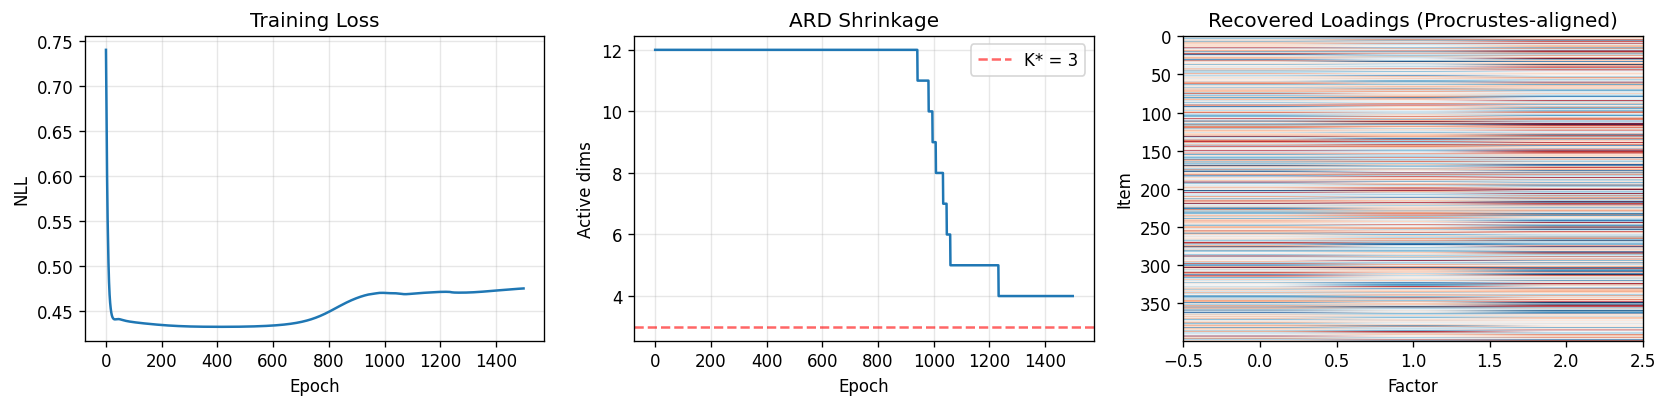

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

axes[0].plot(hist_syn["losses"])
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("NLL")
axes[0].set_title("Training Loss"); axes[0].grid(True, alpha=0.3)

axes[1].plot(hist_syn["active_dims"])
axes[1].axhline(K_TRUE, color="red", linestyle="--", alpha=0.6, label=f"K* = {K_TRUE}")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Active dims")
axes[1].set_title("ARD Shrinkage"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

vmax = float(L_true.abs().max())
axes[2].imshow(L_aligned.numpy(), aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
axes[2].set_title("Recovered Loadings (Procrustes-aligned)")
axes[2].set_xlabel("Factor"); axes[2].set_ylabel("Item")

plt.tight_layout(); plt.show()

Canonical correlations are essentially 1.0 on each of the $K^\star$ true factors — ARAF recovers the loading subspace exactly, and ARD pins the active rank near the truth from the overspecified $K=12$ initialization. With this sanity check passed we move to the real benchmark.

---
## Part 2: Real Benchmark — AfriMedQA (from here on, real-data analysis)

## 2. Load a Measurement-DB Benchmark Dataset

`torch_measure.datasets.load()` returns a `LongFormData` object with long-form responses plus item/subject registries. For the wide-form, matrix-oriented analysis in this tutorial we pivot to a `ResponseMatrix` via `.to_response_matrix()`. We use **AfriMedQA** — a binary-graded medical MCQ benchmark (30 LLMs × ~6,900 items) from measurement-db, the same dataset used in the AmortizedIRT tutorial.

In [7]:
# See what's available in the public measurement-db
print("Available datasets:")
for name in list_datasets():
    ds_info = info(name)
    print(f"  {name:25s}  —  {ds_info.description[:80]}")

Available datasets:


  afrimedqa                  —  AfriMed-QA: medical QA for African healthcare contexts; binary correctness on MC
  agentdojo                  —  AgentDojo: prompt-injection evaluation across many tool-using agents and environ
  ai2d_test                  —  Build AI2D_TEST response matrix from VLMEval/OpenVLMRecords
  androidworld               —  AndroidWorld: 116-task Android agent benchmark; per-task data from 3 public agen
  bfcl                       —  Build a per-task binary response matrix and extract per-task error types from BF
  cybench                    —  Cybench CTF agent benchmark: 8 models x 40 tasks, unguided + subtask-guided mode
  hle                        —  Humanity's Last Exam — 2500-question frontier benchmark; per-item binary correct
  livecodebench              —  LiveCodeBench per-sample binary outcomes from submissions; leaderboard-only rows
  matharena                  —  MathArena: uncontaminated math competitions (27 datasets); final-answer accuracy
  ma

In [8]:
# Load AfriMedQA (binary MCQ correctness)
data = load("afrimedqa")
rm = data.to_response_matrix()
print(rm)
print(f"Density: {rm.density:.1%}")
print(f"Overall accuracy: {rm.data[rm.observed_mask].mean():.3f}")
print(f"\nFirst 3 agents: {rm.subject_ids[:3]}")
print(f"First 3 items:  {rm.item_ids[:3]}")
print(f"\nSample item (question text, item 0):")
print(rm.item_contents[0][:300], "..." if len(rm.item_contents[0]) > 300 else "")

# Subsample items for tutorial speed
torch.manual_seed(0)
n_items_sample = min(2000, rm.n_items)
item_sub = torch.randperm(rm.n_items)[:n_items_sample].sort().values
rm = ResponseMatrix(
    data=rm.data[:, item_sub],
    subject_ids=rm.subject_ids,
    item_ids=[rm.item_ids[i] for i in item_sub.tolist()],
    item_contents=[rm.item_contents[i] for i in item_sub.tolist()],
)
print(f"\nAfter subsampling: {rm}")

ResponseMatrix(n_subjects=30, n_items=6910, density=53.51%)
Density: 53.5%
Overall accuracy: 0.642

First 3 agents: ['BioMistral-7B', 'gpt-4', 'gemini_pro']
First 3 items:  ['6f741000c24a01dd', 'e02dafb9c6f716bd', '82862a20d6f19902']

Sample item (question text, item 0):
A 46-year-old woman with a history of relapsing and remitting multiple sclerosis comes to the clinic for review. She has been stable for the past 6 months and is currently treated with oral fingolimod. Neurological examination reveals poor coordination, more marked on the left than the right, althou ...

After subsampling: ResponseMatrix(n_subjects=30, n_items=2000, density=53.44%)


## 3. Generate Item Embeddings

ARAF needs a vector representation of each item. The agent-eval paper uses Llama-3-8B hidden states (dim 4096) and ablates with PCA / sparse-autoencoder features. For this tutorial we use a lighter `sentence-transformers` model that runs on CPU.

Any encoder works — ARAF only needs an `(n_items, embedding_dim)` tensor.

In [9]:
from sentence_transformers import SentenceTransformer

encoder = SentenceTransformer("all-MiniLM-L6-v2")

print(f"Encoding {rm.n_items} items...")
embeddings = encoder.encode(
    rm.item_contents, show_progress_bar=True, convert_to_tensor=True,
).clone()
print(f"Embeddings shape: {embeddings.shape}")

Encoding 2000 items...


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Embeddings shape: torch.Size([2000, 384])


## 4. Train/Test Split: Held-Out Items

The key test for an amortized model is **zero-shot generalization to new items**. We hold out 20% of items entirely and predict their per-cell pass probabilities using only their embeddings. This is the unseen-item evaluation reported in the agent-eval paper.

In [10]:
torch.manual_seed(42)

n_items = rm.n_items
perm = torch.randperm(n_items)
n_train_items = int(0.8 * n_items)

train_item_idx = perm[:n_train_items].sort().values
test_item_idx = perm[n_train_items:].sort().values

print(f"Train items: {len(train_item_idx)}")
print(f"Test items:  {len(test_item_idx)} (held-out, zero-shot)")

train_responses = rm.data[:, train_item_idx]
test_responses = rm.data[:, test_item_idx]
train_embeddings = embeddings[train_item_idx]
test_embeddings = embeddings[test_item_idx]

Train items: 1600
Test items:  400 (held-out, zero-shot)


## 5. Train the ARAF Model

We fit by minimizing the penalized negative log-likelihood (Eq. 9 in agent-eval, 2026):

$$\mathcal{L}_{\mathrm{Bern}} = -\!\!\!\sum_{(i,j)\in\Omega} \big[ y_{ij}\log\mu_{ij} + (1-y_{ij})\log(1-\mu_{ij}) \big] + \lambda_W \|W\|_F^2 + \lambda_\Theta \|\Theta\|_F^2 + \lambda_\tau \|\tau\|_1.$$

The $\ell_1$ schedule for $\tau$ is delayed: held at 0 for `tau_warmup` epochs, then ramped linearly to its target over `ramp_epochs`, with $\tau$-snapping at $10^{-3}$. We **deliberately overspecify** the latent dimension at $K=20$ so ARD has something to prune. We also seed `tau_raw` with random init in $[-0.2, 0.8]$ — uniform init makes every dim look identically promising and pushes the gate to a degenerate "all-on or all-off" regime in this small-$N$ setting. With non-uniform init plus a moderate $\lambda_\tau$, ARD discovers a clean staircase of effective ranks.

In [11]:
n_subjects = rm.n_subjects
embedding_dim = embeddings.shape[1]
LATENT_DIM = 20  # overspecified — ARD will prune

torch.manual_seed(0)
araf = ARAF(
    n_subjects=n_subjects,
    n_items=len(train_item_idx),
    embedding_dim=embedding_dim,
    latent_dim=LATENT_DIM,
    dropout=0.1,
)
# Non-uniform tau init breaks the symmetry that otherwise traps ARD
# in an "all dims equal" basin. Uniform init plus L1 yields all-on or all-off.
with torch.no_grad():
    araf.tau_raw.data = torch.rand(LATENT_DIM) * 1.0 - 0.2

train_mask = ~torch.isnan(train_responses)
history = araf.fit(
    torch.nan_to_num(train_responses, nan=0.0),
    embeddings=train_embeddings,
    mask=train_mask,
    likelihood="bernoulli",
    epochs=1500,
    lambda_tau=0.013,
    tau_warmup=300,
    ramp_epochs=800,
    verbose=True,
)
print(f"\nFinal training loss: {history['losses'][-1]:.4f}")
print(f"Active latent dims:  {history['active_dims'][-1]} / {LATENT_DIM}")


ARAF fitting:   0%|          | 0/1500 [00:00<?, ?it/s]


ARAF fitting:   0%|          | 0/1500 [00:00<?, ?it/s, loss=0.7021, active=16]


ARAF fitting:   0%|          | 0/1500 [00:00<?, ?it/s, loss=0.6974, active=16]


ARAF fitting:   0%|          | 0/1500 [00:00<?, ?it/s, loss=0.6921, active=16]


ARAF fitting:   0%|          | 0/1500 [00:00<?, ?it/s, loss=0.6869, active=16]

...


ARAF fitting:  99%|█████████▊| 1480/1500 [00:06<00:00, 233.72it/s, loss=0.5683, active=10]


ARAF fitting:  99%|█████████▊| 1480/1500 [00:06<00:00, 233.72it/s, loss=0.5683, active=10]


ARAF fitting:  99%|█████████▊| 1480/1500 [00:06<00:00, 233.72it/s, loss=0.5683, active=10]


ARAF fitting: 100%|██████████| 1500/1500 [00:06<00:00, 230.99it/s, loss=0.5683, active=10]


Final training loss: 0.5683
Active latent dims:  10 / 20


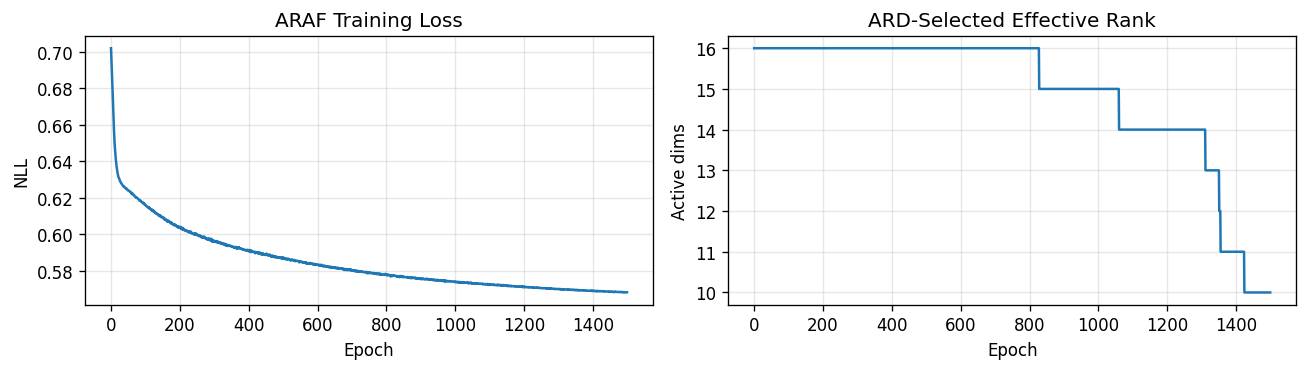

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].plot(history["losses"])
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("NLL")
axes[0].set_title("ARAF Training Loss"); axes[0].grid(True, alpha=0.3)

axes[1].plot(history["active_dims"])
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Active dims")
axes[1].set_title("ARD-Selected Effective Rank"); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Baseline: Standard 2PL (Non-Amortized)

For comparison we fit a standard 2PL on the same training items. Each item has its own free $(b_j, a_j)$ and the model **cannot** generalize to new items.

In [13]:
baseline = TwoPL(n_subjects=n_subjects, n_items=len(train_item_idx))
history_baseline = baseline.fit(
    torch.nan_to_num(train_responses, nan=0.0), mask=train_mask,
    max_epochs=200, verbose=False,
)
print(f"Baseline 2PL final loss: {history_baseline['losses'][-1]:.4f}")
print(f"ARAF final loss:         {history['losses'][-1]:.4f}")

Baseline 2PL final loss: 0.4237
ARAF final loss:         0.5683


## 7. In-Sample Evaluation

Compare how well ARAF and the 2PL baseline fit the training data.

In [14]:
with torch.no_grad():
    probs_araf_train = araf.dense_predict()
    probs_baseline_train = predict_dense(baseline)

ece_araf = expected_calibration_error(probs_araf_train, train_responses, mask=train_mask)
ece_base = expected_calibration_error(probs_baseline_train, train_responses, mask=train_mask)
bs_araf = brier_score(probs_araf_train, train_responses, mask=train_mask)
bs_base = brier_score(probs_baseline_train, train_responses, mask=train_mask)

print(f"{'Metric':<30s} {'ARAF':>12s} {'Baseline 2PL':>14s}")
print("-" * 58)
print(f"{'Brier Score (train)':30s} {bs_araf:12.4f} {bs_base:14.4f}")
print(f"{'ECE (train)':30s} {ece_araf:12.4f} {ece_base:14.4f}")

Metric                                 ARAF   Baseline 2PL
----------------------------------------------------------
Brier Score (train)                  0.1928         0.1410
ECE (train)                          0.0387         0.0197


## 8. Zero-Shot Evaluation on Held-Out Items

This is where amortization matters. We instantiate a fresh `ARAF` for the held-out items, transfer the learned $W$, $\tau$, difficulty head $b$, agent abilities $\Theta$, and biases — then predict directly. **No retraining.**

The 2PL baseline cannot do this at all: its item parameters are independent scalars with no map from item features to parameters.

In [15]:
# Zero-shot transfer: reuse the trained item-side parameters on new items
araf_test = ARAF(
    n_subjects=n_subjects,
    n_items=len(test_item_idx),
    embedding_dim=embedding_dim,
    latent_dim=LATENT_DIM,
    dropout=0.0,
)
araf_test.W.data = araf.W.data.clone()
araf_test.tau_raw.data = araf.tau_raw.data.clone()
araf_test.global_bias.data = araf.global_bias.data.clone()
araf_test.theta.data = araf.theta.data.clone()
araf_test.theta_bias.data = araf.theta_bias.data.clone()
araf_test.difficulty_proj.load_state_dict(araf.difficulty_proj.state_dict())
araf_test.set_embeddings(test_embeddings)

with torch.no_grad():
    probs_araf_test = araf_test.dense_predict()

test_mask = ~torch.isnan(test_responses)
ece_test = expected_calibration_error(probs_araf_test, test_responses, mask=test_mask)
bs_test = brier_score(probs_araf_test, test_responses, mask=test_mask)

print(f"Zero-shot evaluation on {len(test_item_idx)} held-out items:")
print(f"  Brier Score: {bs_test:.4f}")
print(f"  ECE:         {ece_test:.4f}")

Zero-shot evaluation on 400 held-out items:
  Brier Score: 0.2114
  ECE:         0.0324


In [16]:
# Naive baselines on the same held-out items
global_mean = train_responses[~torch.isnan(train_responses)].mean()
bs_naive = brier_score(global_mean.expand_as(test_responses), test_responses, mask=test_mask)

subject_means = train_responses.clone()
subject_means[torch.isnan(subject_means)] = 0.0
train_obs = (~torch.isnan(train_responses)).float()
subject_avg = (subject_means.sum(dim=1) / train_obs.sum(dim=1).clamp(min=1)).unsqueeze(1)
bs_subject = brier_score(subject_avg.expand_as(test_responses), test_responses, mask=test_mask)

print(f"{'Method':<30s} {'Brier Score':>12s}")
print("-" * 44)
print(f"{'Global mean':30s} {bs_naive:12.4f}")
print(f"{'Per-agent mean':30s} {bs_subject:12.4f}")
print(f"{'ARAF (zero-shot)':30s} {bs_test:12.4f}")

Method                          Brier Score
--------------------------------------------
Global mean                          0.2270
Per-agent mean                       0.2144
ARAF (zero-shot)                     0.2114


## 9. Inspect Learned Parameters

We look at the learned per-agent abilities and the ARD gate $\tau$ that decides the effective rank.

In [17]:
# Per-agent ability summary: rank by L2 norm of theta + agent bias
theta = araf.theta.detach()
theta_bias = araf.theta_bias.detach()
agent_score = theta.norm(dim=1) + theta_bias
ranking = agent_score.argsort(descending=True)

print("Top 10 AfriMedQA agents by estimated overall ability:")
for r, idx in enumerate(ranking[:10]):
    print(f"  {r+1:2d}. {rm.subject_ids[idx]:50s}  score={agent_score[idx]:.3f}")

print("\nBottom 5 agents:")
for r, idx in enumerate(ranking[-5:]):
    print(f"  {n_subjects - 4 + r:3d}. {rm.subject_ids[idx]:50s}  score={agent_score[idx]:.3f}")

Top 10 AfriMedQA agents by estimated overall ability:
   1. gpt-4o                                              score=0.774
   2. claude-3-5-sonnet-20240620                          score=0.744
   3. gpt-4                                               score=0.732
   4. Meta-Llama-3-70B-Instruct                           score=0.705
   5. llama3-405b-instruct-maas                           score=0.694
   6. claude-3-opus-20240229                              score=0.621
   7. gpt-4o-mini                                         score=0.511
   8. gpt-4-turbo                                         score=0.405
   9. gemini_ultra                                        score=0.282
  10. PMC-LLaMA-7B                                        score=0.261

Bottom 5 agents:
   26. Phi-3-mini-128k-instruct                            score=-0.012
   27. Mistral-7B-Instruct-v0.3                            score=-0.014
   28. gpt-3.5-turbo-1106                                  score=-0.027
   29. Llama

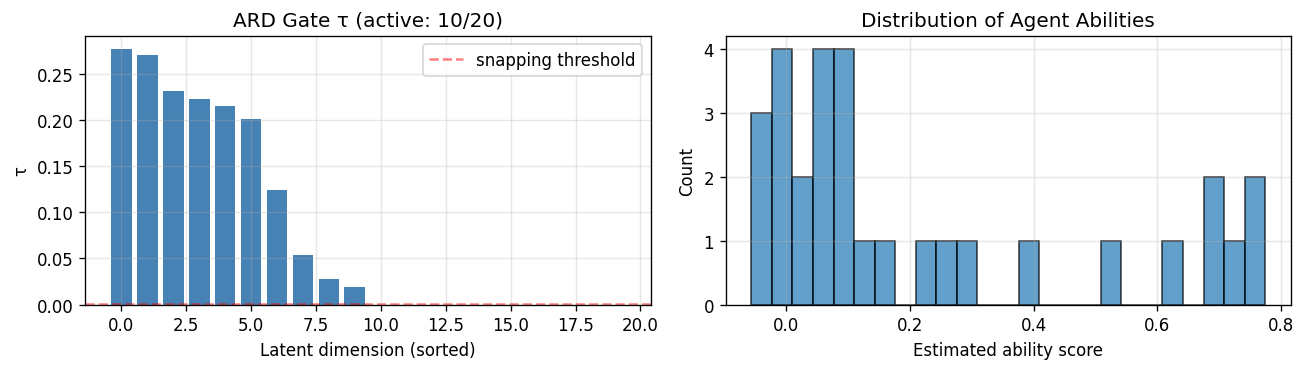

In [18]:
# ARD gate: which latent dims survived
tau = araf.tau.detach().numpy()
tau_sorted = np.sort(tau)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].bar(np.arange(len(tau_sorted)), tau_sorted, color="steelblue")
axes[0].axhline(1e-3, color="red", linestyle="--", alpha=0.5, label="snapping threshold")
axes[0].set_xlabel("Latent dimension (sorted)"); axes[0].set_ylabel("τ")
axes[0].set_title(f"ARD Gate τ (active: {(tau > 1e-3).sum()}/{len(tau)})"); axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(agent_score.numpy(), bins=25, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Estimated ability score"); axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Agent Abilities"); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 10. Held-Out Agents via `adapt()`

ARAF also supports the dual transfer direction: a *new agent* with limited support data on the same item universe. `adapt()` freezes $W$, $\tau$, the difficulty head, and the global bias, and re-fits only $\theta$ and $\beta$ for the new agents.

In [19]:
# Synthetic held-out agents: 5 random agents, only 40% of items observed
torch.manual_seed(7)
n_held = 5
held_idx = torch.randperm(n_subjects)[:n_held]
held_responses = rm.data[held_idx][:, train_item_idx]
held_observe = torch.bernoulli(torch.full(held_responses.shape, 0.4)).bool() & (~torch.isnan(held_responses))

araf_adapt = ARAF(
    n_subjects=n_held, n_items=len(train_item_idx),
    embedding_dim=embedding_dim, latent_dim=LATENT_DIM, dropout=0.0,
)
araf_adapt.set_embeddings(train_embeddings)
araf_adapt.W.data = araf.W.data.clone()
araf_adapt.tau_raw.data = araf.tau_raw.data.clone()
araf_adapt.global_bias.data = araf.global_bias.data.clone()
araf_adapt.difficulty_proj.load_state_dict(araf.difficulty_proj.state_dict())

araf_adapt.adapt(
    torch.nan_to_num(held_responses, nan=0.0), mask=held_observe,
    likelihood="bernoulli", epochs=300, verbose=False,
)

with torch.no_grad():
    p_adapt = araf_adapt.dense_predict()
heldout_cells = (~held_observe) & (~torch.isnan(held_responses))
y_held = held_responses[heldout_cells]
p_held = p_adapt[heldout_cells]
bs_adapt = (p_held - y_held).pow(2).mean().item()
bs_adapt_naive = (y_held.mean() - y_held).pow(2).mean().item()
print(f"Brier on held-out agent cells (ARAF.adapt):  {bs_adapt:.4f}")
print(f"Brier on held-out agent cells (mean):        {bs_adapt_naive:.4f}")

Brier on held-out agent cells (ARAF.adapt):  0.1995
Brier on held-out agent cells (mean):        0.2405


## Summary

In this tutorial we:

1. **Verified** ARAF recovers a known $K^\star$-factor subspace (canonical correlations ≈ 1) and the true rank via ARD on synthetic data.
2. **Loaded** the AfriMedQA benchmark (30 LLMs × 2,000 items) using `torch_measure.datasets.load()`.
3. **Embedded** question text with `sentence-transformers`.
4. **Trained** an `ARAF` model with $K=20$ overspecified latent factors and let ARD prune to the effective rank.
5. **Compared** against a standard 2PL baseline in-sample, and against naive baselines on held-out items.
6. **Evaluated** zero-shot transfer to unseen items by reusing $W, \tau, b, \Theta$ — the regime in which free-item models cannot operate.
7. **Adapted** to held-out agents with `adapt()` — the dual transfer direction.

ARAF is most useful when:
- The item bank is large relative to the number of evaluated agents (small-$N$, large-$J$).
- Item features (text, code, environment metadata) are available and informative about loadings.
- You need predictions for items or agents that were not part of the calibration set.

### Practical note on ARD tuning

The ARD gate has a sharp regime transition: too small a $\lambda_\tau$ keeps every dim alive, too large collapses every dim to zero, and only a narrow band yields a graded ranking. Two tricks help:

- **Overspecify $K$.** Set $K$ several times above what you think is the effective rank — ARD only has something to do if there are dims to remove.
- **Break $\tau$ symmetry at init.** When `tau_raw` starts uniform, every dim sees the same gradient and either all survive or all die. A small random spread (e.g. `Uniform(-0.2, 0.8)`) lets gradients pull dims apart and a sparse solution emerges.

### References
- Benchmark Chisel (2026). *Predicting Agent Performance with Amortized Latent Factor Models.* [github.com/aims-foundations/benchmark-chisel](https://github.com/aims-foundations/benchmark-chisel)
- Truong, P. M. et al. (2025). *Reliable and Efficient Amortized Model-based Evaluation.* [arXiv:2503.13335](https://arxiv.org/abs/2503.13335)